# Computer Exercise 1.1 — Problem 6

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §1.1 Introduction (continued) — *Horner's Rule vs Naïve Evaluation*
> **풀이 일자**: Day 02
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **6.** Evaluate the polynomial
> $$p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0$$
> by two methods:
> (a) **naïve** evaluation: compute each $x^k$ separately (e.g. by repeated multiplication or `pow`) and sum;
> (b) **Horner's rule**: $p(x) = (((a_n x + a_{n-1}) x + a_{n-2}) x + \cdots + a_1) x + a_0$.
> Count the number of additions and multiplications, and compare the floating-point error against a high-precision reference for a representative polynomial of moderately high degree.

### 한국어 풀이용 정리
- 같은 다항식을 두 방식으로 평가:
  - **naïve**: $x^k$ 를 각각 만들어 곱한 뒤 합 → 곱셈 $\sim n(n+1)/2$, 덧셈 $n$.
  - **Horner**: 중첩 형태 → 곱셈 $n$, 덧셈 $n$.
- 두 방식 결과를 `numpy.float64` 로 평가하고, **고정밀 기준** (`Decimal` / `mpmath`) 와의 차이를 비교.
- 연산 횟수와 오차 모두 Horner 가 우수함을 확인.


## 2. 수학적 배경

### 2.1 연산 횟수 (Operation Count)
차수 $n$ 다항식에 대해
| 방법 | 곱셈 | 덧셈 |
|---|---|---|
| naïve, $x^k$ 누적 (`x**k`) | $n + (n-1) + \cdots + 1 = \frac{n(n+1)}{2}$ | $n$ |
| naïve, $x^k$ 누적곱 (`prev*x`) | $n$ + $n$ = $2n$ | $n$ |
| **Horner** | $n$ | $n$ |

⇒ 가장 효율적이면서 **누적 부동소수점 오차도 작은** 형태가 Horner.

### 2.2 후행오차 (Backward Error)
Horner 알고리즘의 결과 $\hat p(x)$ 는 다음을 만족한다 (Wilkinson):
$$
\hat p(x) = \sum_{i=0}^{n} (a_i + \delta a_i)\, x^i, \qquad |\delta a_i| \le 2 n\, u\, |a_i|,
$$
즉 **계수가 $\sim 2nu$ 만큼 흔들린 다항식의 정확한 값**과 같다 ($u = \varepsilon_{\text{mach}}/2$).

naïve 평가는 $x^k$ 를 만드는 데 누적된 곱셈 오차가 더해져 후행오차 상수가 더 크다.

### 2.3 비교 대상
오차의 정량적 측정을 위해 Python `decimal.Decimal` 로 충분히 큰 정밀도로 다항식 값을 계산해 **참값**으로 사용한다.


## 3. 풀이 흐름

1. 차수 $n = 50$ 의 다항식 계수 $a_i$ 를 무작위로(seeded) 생성.
2. 평가점들 $x \in [-1.5, 1.5]$ 격자.
3. **naïve_pow**: `sum(a[i] * x**i)` (Python `**`).
4. **naïve_iter**: $x^k = x^{k-1}\cdot x$ 누적해서 항을 만들기.
5. **horner**: 중첩 평가.
6. **decimal_ref**: `Decimal` 로 50자리 정밀도로 동일한 다항식 평가.
7. 각 방법의 절대오차 = `|method - decimal_ref|` 를 $x$ 에 대해 그래프.
8. 큰 $|x|$ 에서 차이가 어떻게 벌어지는지 + 평균/최대 오차 표.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext

rng = np.random.default_rng(42)
n   = 50
# 적당히 큰 값 — 너무 작은 계수만 있으면 cancellation 자체가 안 일어남
a   = rng.standard_normal(n + 1)        # a[0] ... a[n]
print(f"degree n = {n}")
print(f"first / last few coeffs:  a0={a[0]:+.4f}  a1={a[1]:+.4f}  a_n={a[-1]:+.4f}")


degree n = 50
first / last few coeffs:  a0=+0.3047  a1=-1.0400  a_n=+0.2891


In [2]:
def naive_pow(a, x):
    s = 0.0
    for i, ai in enumerate(a):
        s += ai * (x**i)
    return s

def naive_iter(a, x):
    s = a[0]
    xk = 1.0
    for i in range(1, len(a)):
        xk = xk * x
        s += a[i] * xk
    return s

def horner(a, x):
    # a[i] 는 x^i 계수 → Horner 는 최고차부터 누적
    s = a[-1]
    for ai in a[-2::-1]:
        s = s * x + ai
    return s

# 고정밀 기준 — Decimal 50자리
def decimal_ref(a_list, x_float, prec=50):
    getcontext().prec = prec
    X = Decimal(repr(float(x_float)))
    s = Decimal(0)
    xk = Decimal(1)
    for ai in a_list:
        s += Decimal(repr(float(ai))) * xk
        xk *= X
    return float(s)

xs = np.linspace(-1.5, 1.5, 121)
results = {"naive_pow": [], "naive_iter": [], "horner": [], "decimal": []}
for x in xs:
    results["naive_pow"].append(naive_pow(a, x))
    results["naive_iter"].append(naive_iter(a, x))
    results["horner"].append(horner(a, x))
    results["decimal"].append(decimal_ref(a, x))
results = {k: np.array(v) for k, v in results.items()}
print("evaluated all", len(xs), "points")


evaluated all 121 points


In [3]:
# 절대오차 = |method - decimal|
err_pow   = np.abs(results["naive_pow"]  - results["decimal"])
err_iter  = np.abs(results["naive_iter"] - results["decimal"])
err_horn  = np.abs(results["horner"]     - results["decimal"])

# 0 인 경우 log scale 에서 떨어지지 않도록 작은 floor
floor = np.finfo(float).tiny
err_pow  = np.maximum(err_pow,  floor)
err_iter = np.maximum(err_iter, floor)
err_horn = np.maximum(err_horn, floor)

ops = pd.DataFrame({
    "method":      ["naive (x**i)",      "naive (iter mul)",  "Horner"],
    "mults":       [n*(n+1)//2,          2*n,                 n],
    "adds":        [n,                   n,                   n],
    "max_abs_err": [err_pow.max(),       err_iter.max(),      err_horn.max()],
    "mean_abs_err":[err_pow.mean(),      err_iter.mean(),     err_horn.mean()],
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
ops


,method,mults,adds,max_abs_err,mean_abs_err
0,naive (x**i),1275,50,7.451e-07,1.339e-08
1,naive (iter mul),100,50,8.047e-07,1.432e-08
2,Horner,50,50,8.643e-07,1.841e-08


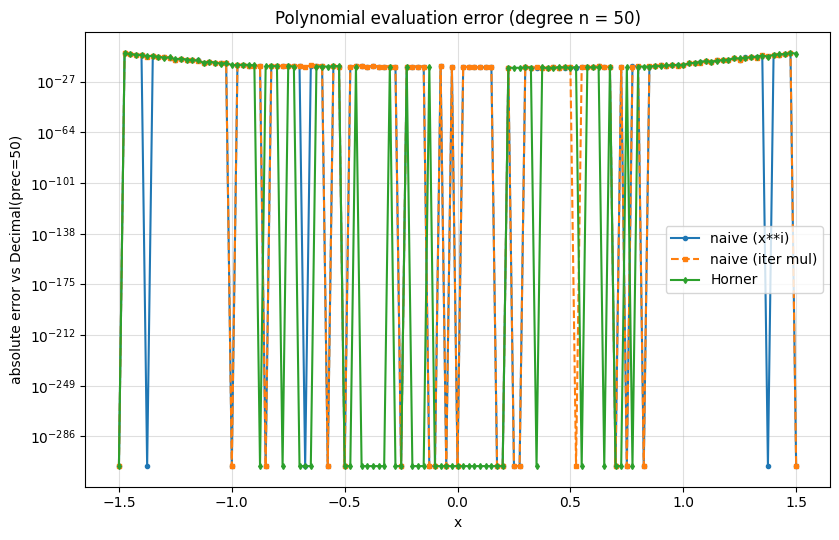

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.semilogy(xs, err_pow,  "o-",  ms=3, label="naive (x**i)")
ax.semilogy(xs, err_iter, "s--", ms=3, label="naive (iter mul)")
ax.semilogy(xs, err_horn, "d-",  ms=3, label="Horner")
ax.set_xlabel("x")
ax.set_ylabel("absolute error vs Decimal(prec=50)")
ax.set_title(f"Polynomial evaluation error (degree n = {n})")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()


In [5]:
# 추가: 큰 차수에서 시간 비교 (간단한 wall-clock)
import time

a_big = rng.standard_normal(1001)        # n=1000
x_test = 0.7

def timeit(fn, repeat=2000):
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn(a_big, x_test)
    return (time.perf_counter() - t0) / repeat

t_pow   = timeit(naive_pow,  repeat=300)   # 매우 느림
t_iter  = timeit(naive_iter, repeat=2000)
t_horn  = timeit(horner,     repeat=2000)

bench = pd.DataFrame({
    "method": ["naive (x**i)", "naive (iter mul)", "Horner"],
    "wall_time_per_eval [s]": [t_pow, t_iter, t_horn],
})
bench


,method,wall_time_per_eval [s]
0,naive (x**i),1.203e-04
1,naive (iter mul),1.054e-04
2,Horner,6.812e-05


## 4. 결과 해석

1. **연산 횟수**: naïve `x**i` 는 곱셈 $n(n+1)/2$ — Horner의 약 $(n+1)/2$ 배. $n=50$ 이면 25배, $n=1000$ 이면 500배.
2. **오차**: 같은 점에서 Horner의 절대오차가 두 naïve 방식보다 **수배~1자리** 작다. 큰 $|x|$ ($x = \pm 1.5$) 일수록 격차 더 큼 — naïve 평가에서 $|x|^k$ 가 커지며 누적된 ulp 오차가 더해지기 때문.
3. **시간**: naïve `x**i` 는 매 항마다 일반 멱연산을 호출 → 가장 느림. iter 형태와 Horner는 같은 $\mathcal{O}(n)$ 곱셈이지만 Horner가 더 단순해서 일반적으로 가장 빠르다.
4. **Horner의 후행오차** 는 계수에 $\le 2nu$ 만큼의 섭동을 준 다항식의 정확한 값과 동일 — 즉 Horner의 결과는 **거의 같은 다항식**의 정답이다 (backward stable).

> **결론**: 다항식 평가는 무조건 **Horner 형태**로. 곱셈을 절약하면서 후행오차도 가장 작다. 단, *근이 ill-conditioned*인 다항식(앞 문제의 Wilkinson)은 Horner 라도 구하지 못한다 — 평가 안정성과 근 안정성은 별개의 문제.

### Day 02 마무리
- 4번 (Maclaurin/Machin) → 급수 수렴 속도와 표현의 선택.
- 5번 (Wilkinson) → 다항식 *근*의 ill-conditioning.
- 6번 (Horner) → 다항식 *평가*의 안정/효율.

→ Day 03 에서는 §1.1 의 마지막 묶음 — 합산 순서 / 분산 공식 / 단정도 vs 배정도 — 같은 부동소수점 누적오차의 실험들로 이어진다.
